In [10]:
%cd stylegan2-ada-pytorch

/teamspace/studios/this_studio/DeepLearningModels/GAN/stylegan2-ada-pytorch


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [9]:
!wget https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl

--2026-03-18 10:11:57--  https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl
Resolving nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)... 3.167.69.13, 3.167.69.8, 3.167.69.24, ...
Connecting to nvlabs-fi-cdn.nvidia.com (nvlabs-fi-cdn.nvidia.com)|3.167.69.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381624121 (364M) [binary/octet-stream]
Saving to: ‘ffhq.pkl’

ffhq.pkl             13%[=>                  ]  47.41M   236MB/s               

ffhq.pkl            100%[===================>] 363.94M   392MB/s    in 0.9s    

2026-03-18 10:11:59 (392 MB/s) - ‘ffhq.pkl’ saved [381624121/381624121]



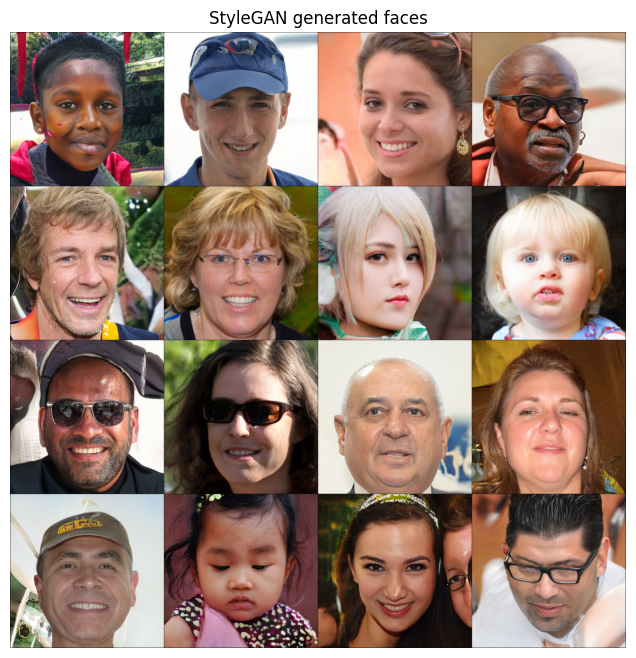

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("ffhq.pkl","rb") as f:
    G=pickle.load(f)["G_ema"].to(device)

z = torch.randn(16, G.z_dim).to(device)

with torch.no_grad():
    images= G(z, None)

images = (images.clamp(-1,1)+1)/2

grid = make_grid(images, nrow=4)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.title("StyleGAN generated faces")
plt.show()


In [1]:
%cd ..

/teamspace/studios/this_studio/DeepLearningModels


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os

os.makedirs("training_images/model3", exist_ok=True)

for i, img in enumerate(images):
    plt.imsave(
        f"training_images/model3/img_{i}.png",
        img.permute(1,2,0).cpu().numpy()
    )

NameError: name 'images' is not defined